In [8]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import numpy as np

# folder path
folder_path = "NBA Shot Data"

# load and sort all csv files
csv_files = sorted(glob.glob(os.path.join(folder_path, "*.csv")))

# read and combine into single df
df = pd.concat(
    [pd.read_csv(file) for file in csv_files],
    ignore_index=True
)

In [9]:
# 1. data preparation (15 years)

df_copy = df.copy()

recent_seasons = [
    '2009-10','2010-11','2011-12','2012-13','2013-14',
    '2014-15','2015-16','2016-17','2017-18','2018-19',
    '2019-20','2020-21','2021-22','2022-23','2023-24'
]

df_recent = df_copy[df_copy['SEASON_2'].isin(recent_seasons)].copy()
df_recent['SHOT_MADE_BINARY'] = df_recent['SHOT_MADE'].astype(int)

print("Total rows:", len(df_recent))
print("Players:", df_recent['PLAYER_NAME'].nunique())

Total rows: 3053916
Players: 1753


In [10]:
# 2. manual AR(1) functions

def fit_ar1_manual(series):
    Y = series[1:]
    X = series[:-1]
    
    X_matrix = np.column_stack((np.ones(len(X)), X))
    beta = np.linalg.inv(X_matrix.T @ X_matrix) @ (X_matrix.T @ Y)
    
    return beta[0], beta[1]

def predict_ar1(series, beta0, beta1):
    return beta0 + beta1 * series[:-1]

In [11]:
# 3. train/test split function

def train_test_split_series(series, split=0.8):
    n = len(series)
    split_idx = int(n * split)
    return series[:split_idx], series[split_idx:]

In [13]:
# 4. loop through players

results = []
all_residuals = []

players = df_recent['PLAYER_NAME'].unique()

for player in players:
    player_df = df_recent[df_recent['PLAYER_NAME'] == player].sort_values('GAME_DATE')
    
    player_df['SHOT_LAG1'] = player_df.groupby('GAME_ID')['SHOT_MADE_BINARY'].shift(1)
    player_df = player_df.dropna(subset=['SHOT_LAG1'])

    series_y = player_df['SHOT_MADE_BINARY'].values
    series_x = player_df['SHOT_LAG1'].values
    
    if len(series_y) < 50:   # ensure stability
        continue
    
    train, test = train_test_split_series(series_y, 0.8)
    
    if len(train) < 2 or len(test) < 2:
        continue
    
    # Fit model on training data
    beta0, beta1 = fit_ar1_manual(train)
    
    # Predictions on test set
    test_preds = beta0 + beta1 * test[:-1]
    test_preds = np.clip(test_preds, 0, 1)

    test_actual = test[1:]
    
    # Metrics
    mse = np.mean((test_actual - test_preds)**2)
    
    # Convert to classification (threshold = 0.5)
    pred_binary = (test_preds >= 0.5).astype(int)
    accuracy = np.mean(pred_binary == test_actual)

    baseline_pred = np.mean(train)

    baseline_preds = np.full(len(test_actual), baseline_pred)
    
    baseline_mse = np.mean((test_actual - baseline_preds)**2)
    baseline_acc = np.mean((baseline_preds >= 0.5) == test_actual)
    
    residuals = test_actual - test_preds
    all_residuals.extend(residuals)
    
    results.append({
        'PLAYER_NAME': player,
        'TOTAL_SHOTS': len(series_y),
        'AR1_COEFFICIENT': beta1,
        'MSE': mse,
        'ACCURACY': accuracy,
        'BASELINE_MSE': baseline_mse,
        'BASELINE_ACC': baseline_acc
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

In [14]:
print("\nModel vs Baseline:")
print("AR(1) Accuracy:", results_df['ACCURACY'].mean())
print("Baseline Accuracy:", results_df['BASELINE_ACC'].mean())

print("\nAR(1) MSE:", results_df['MSE'].mean())
print("Baseline MSE:", results_df['BASELINE_MSE'].mean())


Model vs Baseline:
AR(1) Accuracy: 0.5622281755102717
Baseline Accuracy: 0.564631800754843

AR(1) MSE: 0.245700642272176
Baseline MSE: 0.24461037914911016


In [15]:
# 5. top players table

top_players = results_df.sort_values('AR1_COEFFICIENT', ascending=False).head(10)

print("\nTop 10 Players by AR(1) Coefficient:")
print(top_players)


Top 10 Players by AR(1) Coefficient:
         PLAYER_NAME  TOTAL_SHOTS  AR1_COEFFICIENT       MSE  ACCURACY  \
387       Tim Thomas           88         0.269426  0.277288  0.470588   
283      Malik Allen           89         0.265734  0.261043  0.470588   
1137     Mason Jones          108         0.246120  0.213058  0.714286   
863      Jamel Artis           65         0.243789  0.213152  0.666667   
438   Dexter Pittman           76         0.243590  0.248071  0.666667   
804      Sheldon Mac           54         0.237037  0.241267  0.500000   
1236    Kevon Harris           80         0.233266  0.287247  0.400000   
1289    Rayan Rupert          123         0.211521  0.167501  0.791667   
924      Dzanan Musa          149         0.208372  0.265442  0.655172   
417   Luke Harangody          207         0.205811  0.294131  0.536585   

      BASELINE_MSE  BASELINE_ACC  
387       0.249316      0.529412  
283       0.228549      0.647059  
1137      0.250689      0.476190  
863    

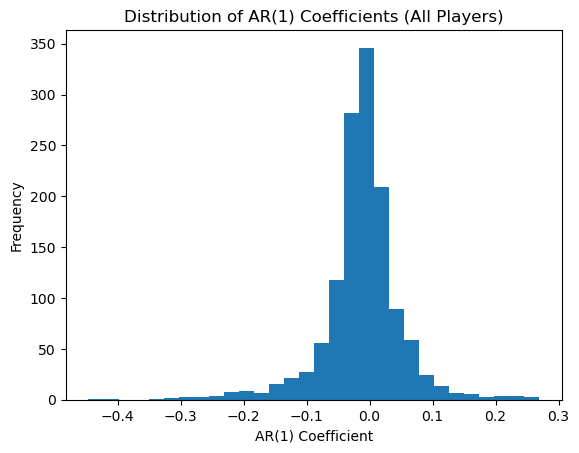

In [16]:
# 6. distribution of AR(1)

plt.figure()
plt.hist(results_df['AR1_COEFFICIENT'], bins=30)
plt.title("Distribution of AR(1) Coefficients (All Players)")
plt.xlabel("AR(1) Coefficient")
plt.ylabel("Frequency")
plt.show()

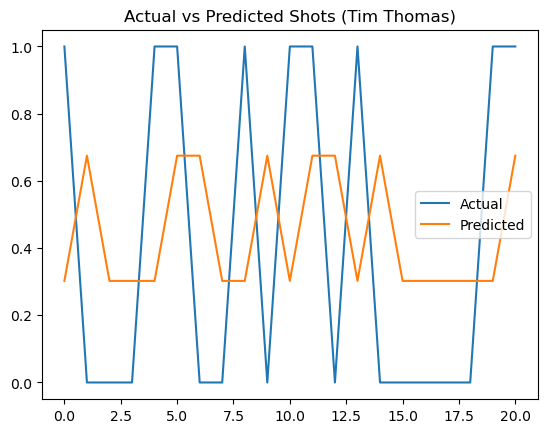

In [17]:
# 7. sample player predictions

sample_player = top_players.iloc[0]['PLAYER_NAME']

player_df = df_recent[df_recent['PLAYER_NAME'] == sample_player].sort_values('GAME_DATE')
series = player_df['SHOT_MADE_BINARY'].values

train, test = train_test_split_series(series, 0.8)

beta0, beta1 = fit_ar1_manual(train)

preds = beta0 + beta1 * test[:-1]
actual = test[1:]

plt.figure()
plt.plot(actual[:100], label='Actual')
plt.plot(preds[:100], label='Predicted')
plt.title(f"Actual vs Predicted Shots ({sample_player})")
plt.legend()
plt.show()

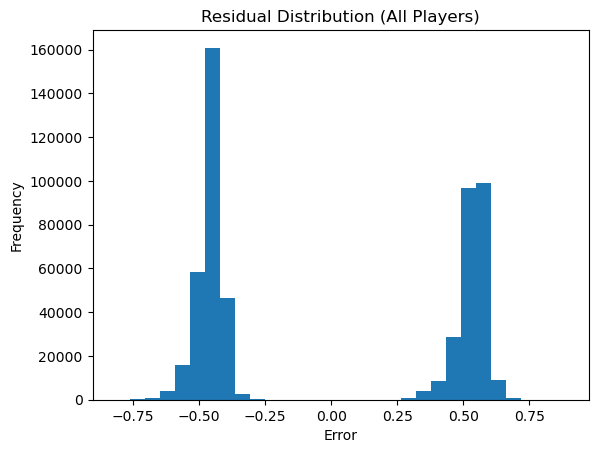

In [18]:
# 8. residual distributions

plt.figure()
plt.hist(all_residuals, bins=30)
plt.title("Residual Distribution (All Players)")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

In [19]:
# 9. summary metrics
print("\nOverall Model Performance:")
print("Average AR(1):", results_df['AR1_COEFFICIENT'].mean())
print("Average MSE:", results_df['MSE'].mean())
print("Average Accuracy:", results_df['ACCURACY'].mean())
print("Baseline Accuracy:", results_df['BASELINE_ACC'].mean())


Overall Model Performance:
Average AR(1): -0.012253271800860492
Average MSE: 0.245700642272176
Average Accuracy: 0.5622281755102717
Baseline Accuracy: 0.564631800754843


In [25]:
# fit and compare AR models

def fit_ar_p(series, p):
    """
    Fit an AR(p) model to a 1D series.
    Returns beta coefficients (intercept + p lags)
    """
    Y = series[p:]
    
    X = np.column_stack([series[p - i - 1 : -i - 1] for i in range(p)])
    X = np.column_stack((np.ones(len(X)), X))
    beta = np.linalg.pinv(X.T @ X) @ (X.T @ Y)
    
    return beta

def predict_ar_p(series, beta, p):
    """
    Predict values for AR(p) model on a series
    """
    preds = []
    for t in range(p, len(series)):
        lags = series[t-p:t][::-1]
        x = np.insert(lags, 0, 1)
        preds.append(x @ beta)
    return np.array(preds)


# compare AR 1, 2, 3

model_results = []

for player in df_recent['PLAYER_NAME'].unique():
    player_df = df_recent[df_recent['PLAYER_NAME'] == player].sort_values('GAME_DATE')
    series = player_df['SHOT_MADE_BINARY'].values
    
    if len(series) < 50:
        continue
    
    # train/test split
    split_idx = int(len(series) * 0.8)
    train = series[:split_idx]
    test = series[split_idx:]
    
    for p in [1, 2, 3]:
        if len(train) <= p or len(test) <= p:
            continue
        
        # fit AR(p) on training data
        beta = fit_ar_p(train, p)
        
        # predict on test data
        preds = predict_ar_p(test, beta, p)
        actual = test[p:]
        
        # compute metrics
        mse = np.mean((actual - preds)**2)
        n = len(actual)
        k = p + 1 
        aic = n * np.log(mse) + 2 * k
        
        model_results.append({
            'PLAYER_NAME': player,
            'MODEL': f'AR({p})',
            'MSE': mse,
            'AIC': aic
        })

# convert results to df
model_df = pd.DataFrame(model_results)

# select best model per player by lowest MSE
best_models = model_df.loc[model_df.groupby('PLAYER_NAME')['MSE'].idxmin()]

# summary
print("Best model counts by AR order:")
print(best_models['MODEL'].value_counts())

Best model counts by AR order:
MODEL
AR(1)    669
AR(3)    394
AR(2)    330
Name: count, dtype: int64
